# Gasperini high-MOI mixture model prototyping

Goal: fit discrete mixture model to high-MOI data (each perturbation may be "active" or "inactive" on its cis targets)

## Data import and subsetting

In [1]:
import mudata as md
import numpy as np
import pandas as pd

import seaborn as sns
import pyro.distributions as dist
from pyro.infer import config_enumerate
from typing import List
from scipy.sparse import spmatrix
from pyro import poutine
import torch

smoke_test=True
if torch.cuda.is_available():
    torch.set_default_device('cuda')
mdata = md.read_h5mu("../../../Data/gasperini_pilot/gasperini_pilot_highMOI.h5mu")
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [2]:
if not smoke_test:
    drop_genes_list = ["U3", "Metazoa_SRP", "Y_RNA"]
    valid_var_names = [x for x in mdata["rna"].var_names if x not in drop_genes_list]
    rna_subset = mdata["rna"][:, valid_var_names]
    tested_genes = rna_subset.varm["element_tested"].sum(axis=1)
    rna_subset = rna_subset[:, tested_genes > 0]
else:
    valid_var_names = ["ACTG1","ACTB"]
    rna_subset = mdata["rna"][:, valid_var_names]
rna_subset

View of AnnData object with n_obs × n_vars = 47964 × 2
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
    varm: 'element_tested'

Subset down to a few interesting genes from the original paper to make comparing results easier

In [3]:
guide_idx, element_idx = np.where(mdata["grna"].varm["element_targeted"])
guide_group_df = pd.DataFrame(dict(guide_idx=guide_idx, element_idx=element_idx))
guide_group_df

,guide_idx,element_idx
0,0,0
1,1,0
2,2,1
3,3,1
4,4,2
...,...,...
3110,3110,1558
3111,3111,1559
3112,3112,1559
3113,3113,1560


In [4]:
gene_idx, element_idx = np.where(rna_subset.varm["element_tested"])
pairs_to_test = pd.DataFrame(dict(gene_idx=gene_idx, element_idx=element_idx))
# pairs_to_test = pairs_to_test.merge(guide_group_df, how="left", on=["element_idx"])  # test by guide
pairs_to_test = pairs_to_test.reset_index(names="pair_idx")
pairs_to_test

,pair_idx,gene_idx,element_idx
0,0,0,1
1,1,1,0
2,2,1,1393


In [5]:
tested_elements = pairs_to_test["element_idx"].unique()
guides_targeted = mdata["grna"].varm["element_targeted"].iloc[:, tested_elements].sum(axis=1) > 0
grna_subset = mdata["grna"][:, guides_targeted]
# grna_subset.varm["element_targeted"] = grna_subset.varm["element_targeted"].iloc[:, tested_elements]
grna_subset

View of AnnData object with n_obs × n_vars = 47964 × 6
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [6]:
mdata = md.MuData({"rna":rna_subset, "grna":grna_subset})
mdata

MuData object with n_obs × n_vars = 47964 × 8
  2 modalities
    rna:	47964 x 2
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 6
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [7]:
cell_idx, guide_idx = np.where(mdata["grna"].X)
guide_obs_df = pd.DataFrame(dict(cell_idx=cell_idx, guide_idx=guide_idx))
guide_obs_df

,cell_idx,guide_idx
0,36,5
1,47,3
2,62,0
3,65,0
4,66,1
...,...,...
2178,47914,1
2179,47927,3
2180,47937,3
2181,47950,0


In [8]:
cell_by_guide_by_gene = pd.merge(pairs_to_test, guide_group_df).merge(guide_obs_df)
cell_by_guide_by_gene


,pair_idx,gene_idx,element_idx,guide_idx,cell_idx
0,0,0,1,2,296
1,0,0,1,2,421
2,0,0,1,2,1125
3,0,0,1,2,1194
4,0,0,1,2,1288
...,...,...,...,...,...
1724,1,1,0,1,47461
1725,1,1,0,1,47463
1726,1,1,0,1,47912
1727,1,1,0,1,47914


In [9]:
cell_by_guide_by_gene = cell_by_guide_by_gene.assign(
    guide_rank = lambda x: x.groupby(["cell_idx", "gene_idx"])["guide_idx"].rank()
)
cell_by_guide_by_gene


,pair_idx,gene_idx,element_idx,guide_idx,cell_idx,guide_rank
0,0,0,1,2,296,1.0
1,0,0,1,2,421,1.0
2,0,0,1,2,1125,1.0
3,0,0,1,2,1194,1.0
4,0,0,1,2,1288,1.0
...,...,...,...,...,...,...
1724,1,1,0,1,47461,1.0
1725,1,1,0,1,47463,1.0
1726,1,1,0,1,47912,1.0
1727,1,1,0,1,47914,1.0


In [10]:
n_max_perturbations = 1

# def make_sparse_tensor_from_df(i, cell_by_guide_by_gene):
n_cells = cell_by_guide_by_gene["cell_idx"].max() + 1
n_genes = cell_by_guide_by_gene["gene_idx"].max() + 1

cell_gene_to_guide_list = []
cell_gene_to_beta_list = []

for i in range(n_max_perturbations):
    filtered_df = cell_by_guide_by_gene.query(f"guide_rank=={i+1}")
    cell_gene_indices = torch.tensor(filtered_df[["cell_idx", "gene_idx"]].values.T)
    guide_indices = torch.tensor(filtered_df["guide_idx"].values) + 1
    beta_indices = torch.tensor(filtered_df["pair_idx"].values) + 1
    cell_gene_to_guide_i = torch.sparse_coo_tensor(cell_gene_indices, guide_indices, size=[n_cells, n_genes])
    cell_gene_to_beta_i = torch.sparse_coo_tensor(cell_gene_indices, beta_indices, size=[n_cells, n_genes])
    cell_gene_to_guide_list.append(cell_gene_to_guide_i)
    cell_gene_to_beta_list.append(cell_gene_to_beta_i)
# make_sparse_tensor_from_df(0, cell_by_guide_by_gene).shape
# cell_gene_to_guide=torch.stack([make_sparse_tensor_from_df(i, cell_by_guide_by_gene) for i in range(n_max_enum)], dim=-1)
cell_gene_to_guide = torch.stack(cell_gene_to_guide_list, dim=-1).to_dense() - 1
cell_gene_to_guide[cell_gene_to_guide == -1] = mdata["grna"].n_vars
cell_gene_to_beta = torch.stack(cell_gene_to_beta_list, dim=-1).to_dense() - 1
cell_gene_to_guide[cell_gene_to_beta == -1] = len(pairs_to_test)
cell_gene_to_guide.shape

torch.Size([47964, 2, 1])

In [20]:
from guide_mixture import model, compute_combinatorial_matrix

from collections import namedtuple

Args = namedtuple("Args", ["num_epochs", "num_guides", "num_genes", "num_cells", "max_targeting_cell"])
args = Args(
    500,
    mdata["grna"].n_vars,
    mdata["rna"].n_vars,
    mdata.n_obs,
    n_max_perturbations,
)
# parser.add_argument("--num-epochs", default=15000, type=int)
# parser.add_argument("--num-genes", default=6, type=int)
# parser.add_argument("--num-guides", default=4, type=int)
# parser.add_argument("--num-cells", default=8, type=int)
# parser.add_argument("--max-targeting-cell", default=3, type=int)

log_library_size = torch.tensor(mdata["rna"].obs["log_total_gene_count"].values[:,None])
size_factor = log_library_size - log_library_size.mean()
assert size_factor.isnan().sum() == 0
data = {
    "Y": torch.tensor(mdata["rna"].X.todense()),  # only works for subset
    "size_factor": size_factor,
    "cell_gene_to_guide": cell_gene_to_guide.to_dense(),  # only works for subset
    "cell_gene_to_beta": cell_gene_to_beta.to_dense(),  # only works for subset
    "cell_guide_mask": torch.tensor(mdata["grna"].X),
    "total_guide_gene_interactions": len(pairs_to_test),
    "combinatorial_matrix": compute_combinatorial_matrix(args),
    "flip_combinatorial_matrix": 1 - compute_combinatorial_matrix(args),
}
data["total_guide_gene_interactions"]
model(data, args)
#

In [21]:
from pyro.infer import SVI, TraceMeanField_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
import pyro.optim as optim
import pyro

pyro.clear_param_store()
guide = AutoDiagonalNormal(model)
svi = SVI(model, guide, optim.Adam({'lr': 0.1}), loss=TraceMeanField_ELBO())

for k in range(args.num_epochs):
    loss = svi.step(data, args)

    if k % 100 == 0 or k == args.num_epochs - 1:
        print("[epoch %04d] training elbo: %.6g" % (k, -loss))
        param_store = pyro.get_param_store()
        median = guide.median()
        print(param_store["beta_0"].detach(), param_store["nu"].detach())



[epoch 0000] training elbo: -930402
tensor([0.1000, 0.1000]) tensor([0.9048, 0.9048])
[epoch 0100] training elbo: -322092
tensor([2.0265, 2.8931]) tensor([2.2243, 1.7907])
[epoch 0200] training elbo: -312939
tensor([2.0240, 2.9225]) tensor([2.2265, 5.6922])
[epoch 0300] training elbo: -312938
tensor([2.0243, 2.9225]) tensor([2.2267, 5.7737])
[epoch 0400] training elbo: -312941
tensor([2.0239, 2.9226]) tensor([2.2267, 5.7735])
[epoch 0499] training elbo: -312937
tensor([2.0241, 2.9228]) tensor([2.2267, 5.7734])


In [22]:
import pyro
param_store = pyro.get_param_store()
for k, v in param_store.items():
    print(k, v.shape)
guide.median()["beta"]
guide.quantiles([0.05, 0.95])["beta"]

nu torch.Size([2])
beta_0 torch.Size([2])
targeting_efficiencies torch.Size([6])
cell_guide_presence_prob torch.Size([47964, 6])
AutoDiagonalNormal.loc torch.Size([3])
AutoDiagonalNormal.scale torch.Size([3])


tensor([[-1.2521, -0.8433, -0.1547],
        [-1.0880, -0.7384,  0.2105]])

In [23]:
pd.DataFrame(param_store["targeting_efficiencies"].detach().cpu().numpy(), index=mdata["grna"].var_names, columns=["efficiency"])
# pd.DataFrame(guide.median()["beta"].detach().cpu().numpy(), index=mdata["grna"].var_names, columns=["efficiency"])

,efficiency
ACTB_TSS|1,0.714733
ACTB_TSS|2,0.555243
ACTG1_TSS|1,0.889581
ACTG1_TSS|2,0.453549
chr7:5613818-5613841|1,0.776853
chr7:5613818-5613841|2,0.776853


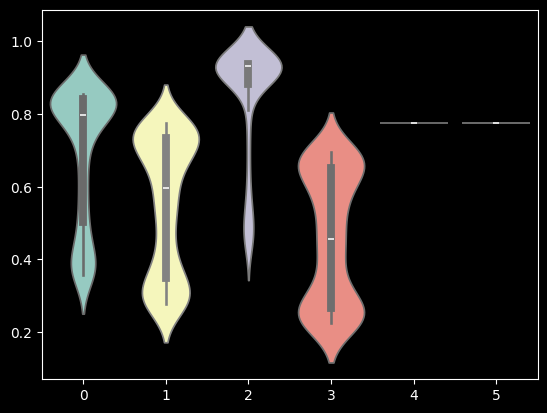

In [24]:
probs = param_store["cell_guide_presence_prob"].detach().numpy()
for i in range(mdata["grna"].n_vars):
    probs_i = probs[:,i][mdata["grna"].X[:,i]>0]
    sns.violinplot(x=i, y=probs_i)

In [15]:
stacked_tensor[2,...]

NameError: name 'stacked_tensor' is not defined

In [13]:
from scipy.sparse import csr_matrix, csc_matrix, csr_array, csc_array

rna_adata = rna_subset
grna_adata = mdata["grna"]
# grna_counts = csr_matrix(mdata["grna"].X)
cell_by_guide = csr_matrix(grna_adata.X)
guide_by_element = grna_adata.varm["element_targeted"].values
element_by_gene = rna_adata.varm["element_tested"].values.T
guide_by_gene = (guide_by_element @ element_by_gene_dist) > 0

assert cell_by_guide.max() == 1
assert guide_by_element.max() == 1
assert element_by_gene_dist.max() == 1
n_cells, n_guides = cell_by_guide.shape
n_genes = guide_by_gene.shape[1]

print(n_genes)


NameError: name 'element_by_gene_dist' is not defined

In [ ]:
from tqdm import tqdm
from scipy.sparse import coo_matrix

n_enum_guides = 3

print("Extracting cell:gene pairs")
guide_gene_dict = dict()
guide_by_element_dict = {i: j for i, j in zip(*guide_by_element.nonzero())}
element_by_gene_map = {
    i: np.nonzero(element_by_gene[:, i])[0].tolist() for i in range(n_genes)
}
indices = []
values = []
for cell_idx, guide_idx in zip(*cell_by_guide.nonzero()):
    element = guide_by_element_dict[guide_idx]
    target_genes = element_by_gene_map[element]
    for g in target_genes:
        indices.append((cell_idx, g))
        values.append(guide_idx)

print("Extracting top 3 guides per cell:gene pair")
cell_by_gene_sparse = []
for guide_number in range(n_enum_guides):
    print(f"guide {guide_number}")
    # get the first unique occurrence of each index and its value
    idx_pairs = {idx: i for i, idx in enumerate(indices)}
    unique_indices = list(idx_pairs.keys())
    selected_indices = frozenset(idx_pairs.values())
    unique_values = [values[i] + 1 for i in selected_indices]

    cell_by_gene_sparse.append(
        coo_matrix((unique_values, zip(*unique_indices)), shape=(n_cells, n_genes))
    )
    # remove the unique indices and values from the lists
    indices = [idx for i, idx in enumerate(indices) if i not in selected_indices]
    values = [v for i, v in enumerate(values) if i not in selected_indices]


Extracting cell:gene pairs
Extracting top 3 guides per cell:gene pair
guide 0
guide 1
guide 2


In [ ]:
import torch

n_elements = 3
guide_by_element = torch.ones((n_guides, n_elements))
element_effects = torch.ones((n_elements, n_genes))
guide_effects = guide_by_element @ element_effects

guide_efficiency = torch.ones((n_guides, n_genes))

# unravel the cell_by_gene_sparse matrix, use it to index into the guide_by_element and element_effects tensors

# convert to tensor
cell_by_gene_sparse_tensors = [
    torch.tensor(x.toarray(), dtype=torch.long) for x in cell_by_gene_sparse
]
for cell_by_gene in cell_by_gene_sparse_tensors:
    # cell_idx, gene_idx = cell_by_gene.nonzero()
    # guide_by_gene_flat = cell_by_gene.flatten() - 1
    # cell_by_guide_efficiency = guide_efficiency[:, cell_by_gene - 1]
    # cell_by_guide_effect = guide_effects[guide_by_gene_flat, :]
    # print(cell_by_guide_effect.shape)
    # .unflatten(0, cell_by_gene.shape)


SyntaxError: incomplete input (2100031951.py, line 22)

In [ ]:
for i in range(n_enum_guides):
    rna_subset.layers[f"guide_idx_{i}"] = cell_by_gene_sparse[i]
rna_subset

/tmp/ipykernel_6526/1931635857.py:2: ImplicitModificationWarning: Setting element `.layers['guide_idx_0']` of view, initializing view as actual.
  rna_subset.layers[f"guide_idx_{i}"] = cell_by_gene_sparse[i]


AnnData object with n_obs × n_vars = 47964 × 7058
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
    varm: 'element_tested'
    layers: 'guide_idx_0', 'guide_idx_1', 'guide_idx_2'

In [ ]:
rna_subset.layers["guide_idx_0"].shape

(47964, 7058)

<function torch._VariableFunctionsClass.index_select>

In [ ]:
# from scipy.sparse import coo_matrix, dok_matrix
# from tqdm import tqdm

# n_guide_enum = 3

# guides_sparse = [
#     dok_matrix((n_cells, n_genes), dtype=np.int32) for _ in range(n_guide_enum)
# ]
# for i in tqdm(range(rna_subset.n_vars)):
#     guide_cts = cell_by_guide.multiply(guide_by_element @ element_by_gene_dist[:, i])
#     assert guide_cts.shape == cell_by_guide.shape
#     cell_idx, guide_idx = np.nonzero(guide_cts)

#     for j in range(n_guide_enum):
#         cell_idx_new = []
#         guide_idx_new = []

#         cell_guide_dict = dict()
#         for cell, guide in zip(cell_idx, guide_idx):
#             if cell not in cell_guide_dict:
#                 cell_guide_dict[cell] = guide
#                 guides_sparse[j][cell, i] = guide
#             else:
#                 cell_idx_new.append(cell)
#                 guide_idx_new.append(guide)

#         cell_idx = cell_idx_new
#         guide_idx = guide_idx_new
#         # guides_sparse.append(sparse_guide_cts)
#         # guides_sparse.append(sparse_guide_cts)
#     # guides_sparse[0]


In [ ]:
# guides_sparse[1]

Use the "element_tested" matrix to figure out which elements are in *cis* of the genes of interest

In [ ]:
element_tested_indices = np.nonzero(rna_subset.varm["element_tested"])[1]
subset_elements = rna_subset.varm["element_tested"].iloc[:,element_tested_indices].columns.tolist()
subset_elements

['scrambled_21',
 'random_6',
 'RER1_TSS',
 'RER1_TSS',
 'RER1_TSS',
 'RER1_TSS',
 'RER1_TSS',
 'RER1_TSS',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr1:2472004-2472027',
 'RER1_TSS',
 'chr

In [ ]:
rna_subset.varm["element_tested"] = rna_subset.varm["element_tested"][subset_elements]
rna_subset.varm["element_tested"]

,scrambled_21,random_6,RER1_TSS,RER1_TSS,RER1_TSS,RER1_TSS,RER1_TSS,RER1_TSS,RER1_TSS,chr1:2472004-2472027,...,chrX:153118933-153118956,chrX:153118933-153118956,chrX:153118933-153118956,chrX:153118933-153118956,random_4,chrX:153118933-153118956,chrX:153118933-153118956,chrX:153118933-153118956,chrX:153118933-153118956,scrambled_13
PLEKHN1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ISG15,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCNL2,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MRPL20-AS1,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MRPL20,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RENBP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
HCFC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
TMEM187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
IRAK1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


Now, use the guide by element "element_targeted" matrix to figure out which guides target those elements

In [ ]:

element_targeted_for_subset_elements = mdata["grna"].varm["element_targeted"][subset_elements]
element_targeted_for_subset_elements


,scrambled_21,random_6,RER1_TSS,RER1_TSS,RER1_TSS,RER1_TSS,RER1_TSS,RER1_TSS,RER1_TSS,chr1:2472004-2472027,...,chrX:153118933-153118956,chrX:153118933-153118956,chrX:153118933-153118956,chrX:153118933-153118956,random_4,chrX:153118933-153118956,chrX:153118933-153118956,chrX:153118933-153118956,chrX:153118933-153118956,scrambled_13
ACTB_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
element_targeted_subset = element_targeted_for_subset_elements[element_targeted_for_subset_elements.sum(axis=1)>0]
subset_guides = element_targeted_subset.index
subset_guides

Index(['ACTB_TSS|1', 'ACTB_TSS|2', 'ACTG1_TSS|1', 'ACTG1_TSS|2', 'ACYP1_TSS|1',
       'ACYP1_TSS|2', 'ADIPOR1_TSS|1', 'ADIPOR1_TSS|2', 'ALDH1A2_TSS|1',
       'ALDH1A2_TSS|2',
       ...
       'scrambled_5|1', 'scrambled_5|2', 'scrambled_6|1', 'scrambled_6|2',
       'scrambled_7|1', 'scrambled_7|2', 'scrambled_8|1', 'scrambled_8|2',
       'scrambled_9|1', 'scrambled_9|2'],
      dtype='object', length=3052)

In [ ]:
grna_subset = mdata["grna"][:, subset_guides]
grna_subset.varm["element_targeted"] = element_targeted_for_subset_elements.loc[subset_guides]
grna_subset

/tmp/ipykernel_6526/2691310224.py:2: ImplicitModificationWarning: Setting element `.varm['element_targeted']` of view, initializing view as actual.
  grna_subset.varm["element_targeted"] = element_targeted_for_subset_elements.loc[subset_guides]


AnnData object with n_obs × n_vars = 47964 × 3052
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

Finally, construct a new MuData object containing only the cells targeted by the perturbations of interest, plus an equal number of non-targeted cells

**This part is for testing purposes only, not meant for production**

In [ ]:
targeted_cells, = np.nonzero(grna_subset.X.sum(axis=1)>0)
len(targeted_cells)

47497

In [ ]:
n_random_cells = len(targeted_cells)
random_cells = np.random.choice(
    [i for i in range(mdata.n_obs) if i not in targeted_cells], n_random_cells
)
len(random_cells)

47497

In [ ]:
subset_cells = np.concatenate((targeted_cells, random_cells))
mdata_subset = md.MuData({"rna":rna_subset[subset_cells], "grna": grna_subset[subset_cells]})
mdata_subset

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/mudata/_core/mudata.py:407: UserWarning: Duplicated obs_names should not be present in different modalities due to the ambiguity that leads to.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull

KeyboardInterrupt: 

In [ ]:
from scipy.sparse import csr_matrix
n_target_guides_per_cell = mdata_subset["grna"].X.sum(axis=1)
sns.histplot(n_target_guides_per_cell, binwidth=1)

In [ ]:
elements = mdata_subset["rna"].varm["element_tested"].columns 
assert (elements == mdata_subset["grna"].varm["element_targeted"].columns).all()

In [ ]:
import torch
import pyro

gene_cts = mdata_subset["rna"].X
guide_cts = mdata_subset["grna"].X
guide_by_element_targeted = mdata_subset["grna"].varm["element_targeted"].values
gene_by_element_tested = mdata_subset["rna"].varm["element_tested"].values

# gene_by_element_tested = torch.tensor(mdata_subset["rna"].varm["element_tested"].values, dtype=torch.bool)

# gene_cts = torch.tensor(mdata_subset["rna"].X.todense(), dtype=torch.float32)
# guide_cts = torch.tensor(mdata_subset["grna"].X, dtype=torch.bool)
# guide_by_element_targeted = torch.tensor(mdata_subset["grna"].varm["element_targeted"].values, dtype=torch.bool)
# gene_by_element_tested = torch.tensor(mdata_subset["rna"].varm["element_tested"].values, dtype=torch.bool)


# validate that data matches along axes
elements = mdata_subset["rna"].varm["element_tested"].columns
assert (elements == mdata_subset["grna"].varm["element_targeted"].columns).all()
assert gene_cts.shape[0] == guide_cts.shape[0]  # n_cells
assert (
    guide_by_element_targeted.shape[1] == gene_by_element_tested.shape[1]
)  # n_elements
assert gene_cts.shape[1] == gene_by_element_tested.shape[0]  # n_genes
assert guide_cts.shape[1] == guide_by_element_targeted.shape[0]  # n_guidess


In [ ]:
from scipy.sparse import coo_matrix

n_guide_enum = 3

cell_idx, guide_idx = np.nonzero(guide_cts)

guides_sparse = []
for _ in range(n_guide_enum):
    cell_idx_new = []
    guide_idx_new = []

    cell_guide_dict = dict()
    for cell, guide in zip(cell_idx, guide_idx):
        if cell not in cell_guide_dict:
            cell_guide_dict[cell] = guide
        else:
            cell_idx_new.append(cell)
            guide_idx_new.append(guide)

    sparse_guide_cts = coo_matrix(
        (
            np.ones(len(cell_guide_dict)),
            (
                list(cell_guide_dict.keys()),
                list(cell_guide_dict.values()),
            ),
        ),
        shape=guide_cts.shape,
    )
    cell_idx = cell_idx_new
    guide_idx = guide_idx_new
    guides_sparse.append(sparse_guide_cts)
guides_sparse[0]


Load model args into tensors

In [ ]:
gene_cts_tensor = torch.tensor(gene_cts.todense(), dtype=torch.float32).squeeze()
guides_sparse_tensor = [
    torch.tensor(guide_cts.todense(), dtype=torch.float32)
    for guide_cts in guides_sparse
]
guide_by_element_targeted_tensor = torch.tensor(
    guide_by_element_targeted, dtype=torch.float32
)
lib_size = torch.tensor(
    mdata_subset["rna"].obs["log_total_gene_count"].values, dtype=torch.float32
).exp()

size_factor = lib_size / lib_size.mean()

assert (lib_size > 0).all()
lib_size.shape
# gene_cts_tensor.shape

In [ ]:
# import pyro.distributions as dist
# from pyro.infer import config_enumerate
# from typing import List
# from scipy.sparse import spmatrix
# from pyro import poutine


# @config_enumerate(default="parallel")
# def model_single_gene(
#     gene_cts,
#     guides_sparse,
#     guide_by_element_targeted,
#     size_factor,
#     use_mixture=True,
#     share_efficiency=False,
# ):
#     n_cells, n_genes = gene_cts.shape
#     # _, n_guides = guide_cts.shape
#     n_guides, n_elements = guide_by_element_targeted.shape
#     n_guides_enum = len(guides_sparse)

#     assert n_genes == 1

#     cell_plate = pyro.plate("cells", n_cells, dim=-2)
#     guide_plate = pyro.plate("guides", n_guides, dim=-2)
#     element_plate = pyro.plate("elements", n_elements, dim=-2)
#     # gene_plate = pyro.plate("genes", n_genes, dim=-1)
#     # guide_enum_plate = pyro.plate("guides_enum", n_guides_enum)

#     gene_mean = pyro.sample("gene_mean", dist.LogNormal(0, 3))
#     gene_dispersion = pyro.sample("gene_dispersion", dist.Gamma(1, 1))

#     if share_efficiency:
#         guide_efficiency = pyro.sample("guide_efficiency", dist.Beta(2, 1)).expand(
#             n_guides, -1
#         )
#     else:
#         with guide_plate:
#             # guide_efficiency: n_guides x 1
#             guide_efficiency = pyro.sample("guide_efficiency", dist.Beta(2, 1))

#     with element_plate:
#         # element_effect: n_elements x 1
#         element_effect = pyro.sample("beta", dist.Normal(0, 1))
#     guide_effect = guide_by_element_targeted @ element_effect

#     cell_guide_effects = list()
#     # for i in guide_enum_plate:
#     for i in range(n_guides_enum):
#         # guide_cts_enum: n_cells x n_guides
#         guide_cts_enum = guides_sparse[i]

#         # guide_present: n_cells x 1
#         # did the ith guide in this cell have an effect?
#         guide_cts_enum_mask = guide_cts_enum.sum(axis=1, keepdim=True) > 0
#         with cell_plate, poutine.mask(mask=guide_cts_enum_mask):
#             if use_mixture:
#                 guide_active_i = pyro.sample(
#                     f"guide_active_{i}",
#                     dist.Bernoulli(probs=guide_cts_enum @ guide_efficiency),
#                 )
#             else:
#                 guide_active_i = guide_cts_enum * guide_efficiency.squeeze()

#         # what is the effect, if the guide is present?
#         element_effect_i = (guide_cts_enum * guide_active_i) @ guide_effect

#         cell_guide_effects.append(element_effect_i)

#     logits = gene_mean.log() + sum(cell_guide_effects) + size_factor.log()
#     with cell_plate:
#         pyro.sample(
#             "counts",
#             dist.NegativeBinomial(
#                 total_count=gene_dispersion, logits=logits - gene_dispersion.log()
#             ),
#             obs=gene_cts,
#         )


# pyro.render_model(
#     model_single_gene,
#     (gene_cts_tensor, guides_sparse_tensor, guide_by_element_targeted_tensor, lib_size),
# )

In [ ]:
import pyro.distributions as dist
from pyro.infer import config_enumerate
from typing import List
from scipy.sparse import spmatrix
import pyro


@config_enumerate(default="parallel")
def model_single_gene(
    gene_cts,
    guides_sparse,
    guide_by_element_targeted,
    size_factor,
    use_mixture=True,
    share_efficiency=False,
):
    (n_cells,) = gene_cts.shape
    # _, n_guides = guide_cts.shape
    n_guides, n_elements = guide_by_element_targeted.shape
    n_guides_enum = len(guides_sparse)

    cell_plate = pyro.plate("cells", n_cells)
    guide_plate = pyro.plate("guides", n_guides)
    element_plate = pyro.plate("elements", n_elements)
    # gene_plate = pyro.plate("genes", n_genes, dim=-1)
    # guide_enum_plate = pyro.plate("guides_enum", n_guides_enum)

    gene_mean = pyro.sample("gene_mean", dist.LogNormal(0, 3))
    gene_dispersion = pyro.sample("gene_dispersion", dist.Gamma(1, 1))

    if share_efficiency:
        guide_efficiency = pyro.sample("guide_efficiency", dist.Beta(2, 1))
    else:
        with guide_plate:
            # guide_efficiency: (n_guides,)
            guide_efficiency = pyro.sample("guide_efficiency", dist.Beta(2, 1))

    with element_plate:
        # element_effect: (n_elements,)
        element_effect = pyro.sample("beta", dist.Normal(0, 1))
    guide_effect = guide_by_element_targeted @ element_effect

    cell_guide_effects = list()
    # for i in guide_enum_plate:
    for i in range(n_guides_enum):
        # guide_cts_enum: n_cells x n_guides
        guide_cts_enum = guides_sparse[i]

        # guide_present: n_cells x 1
        # did the ith guide in this cell have an effect?
        guide_cts_enum_mask = guide_cts_enum.sum(axis=-1) > 0
        with cell_plate, poutine.mask(mask=guide_cts_enum_mask):
            if use_mixture:
                guide_probs = guide_cts_enum @ guide_efficiency
                guide_active_i = pyro.sample(
                    f"guide_active_{i}", dist.Bernoulli(probs=guide_probs)
                )
            else:
                guide_active_i = guide_cts_enum * guide_efficiency

        # what is the effect, if the guide is present?
        element_effect_i = guide_cts_enum @ guide_effect * guide_active_i
        cell_guide_effects.append(element_effect_i)

    logits = gene_mean.log() + sum(cell_guide_effects) + size_factor.log()
    with cell_plate:
        obs = pyro.sample(
            "counts",
            dist.NegativeBinomial(
                total_count=gene_dispersion, logits=logits - gene_dispersion.log()
            ),
            obs=gene_cts,
        )
    return obs


pyro.render_model(
    model_single_gene,
    (
        gene_cts_tensor,
        guides_sparse_tensor,
        guide_by_element_targeted_tensor,
        lib_size,
    ),
)

In [ ]:
import pyro.optim as optim
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO
from pyro.infer.autoguide import AutoNormal, init_to_value, init_to_median
from pyro import poutine
from functools import partial

print(n_guide_enum)
# Initialize the model and guide
pyro.clear_param_store()

model = model_single_gene
# model = partial(model, use_mixture=True, )
guide = AutoNormal(
    poutine.block(
        config_enumerate(model, "sequential"),
        hide=[f"guide_active_{i}" for i in range(n_guide_enum)],
    ),
    init_loc_fn=init_to_value(
        values={
            "gene_mean": torch.tensor(gene_cts.mean()),
            "gene_dispersion": torch.tensor(10.0),
        },
        fallback=init_to_median(num_samples=100),
    ),
)

# Define the optimizer
optimizer = optim.ClippedAdam({"lr": 0.01, "lrd": 0.999})

# Define the loss function
elbo = TraceEnum_ELBO(max_plate_nesting=2)

# Create the SVI object
svi = SVI(model, guide, optimizer, loss=elbo)

# Train the model
num_steps = 2000
for step in range(num_steps):
    loss = svi.step(
        gene_cts_tensor.T,
        guides_sparse_tensor,
        guide_by_element_targeted_tensor,
        size_factor,
    )
    if step % 100 == 0:
        print(f"Step {step}/{num_steps}, Loss: {loss}")


In [ ]:
for k,v in pyro.get_param_store().items():
    print(k, v)

In [ ]:
guide.median()

In [ ]:
guide.quantiles([0.05, 0.95])

In [ ]:
import matplotlib.pyplot as plt

element_effect = guide.median()["beta"].squeeze()
element_names = mdata_subset["rna"].varm["element_tested"].columns

plt.figure(figsize=(10, 6))
plt.bar(element_names, element_effect)
plt.xlabel("Element")
plt.ylabel("Effect Size")
plt.title("Estimated Effect Size for Each Element")
plt.xticks(rotation=90)
plt.show()